<a href="https://colab.research.google.com/github/vimaladevi17/Datascience_lab/blob/main/exp5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

===== Random Forest =====
AUC: 0.8948547764919447
Precision: 0.7961165048543689
Recall: 0.7256637168141593

===== Gradient Boosting =====
AUC: 0.8797367823916498
Precision: 0.8
Recall: 0.7433628318584071


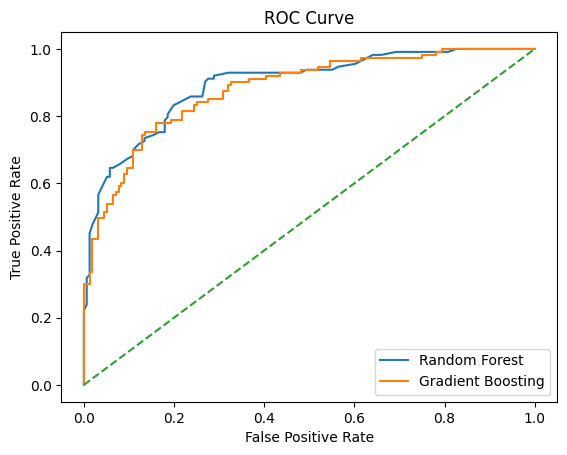

In [ ]:
Experiment Title
Implementation of Random Forest and Gradient Boosting Models and Evaluation using AUC, Precision, and Recall
 Aim:
To implement Random Forest and Gradient Boosting classification algorithms using Python and evaluate their performance using AUC, Precision, and Recall metrics.
 Description:
Machine Learning ensemble methods improve prediction accuracy by combining multiple models.
🔹 Random Forest
Random Forest is a bagging-based ensemble learning algorithm that constructs multiple decision trees during training and
 combines their outputs to improve accuracy and reduce overfitting.
Features:
Uses multiple decision trees
Reduces variance and overfitting
Provides better generalization performance
Suitable for classification and regression problems
🔹 Gradient Boosting
Gradient Boosting is a boosting-based ensemble method that builds trees sequentially.
Each new tree attempts to correct the errors made by the previous trees.
Features:
Sequential learning approach
Improves prediction accuracy
Handles complex data patterns
Powerful for classification tasks
 Performance Evaluation Metrics:
The models are evaluated using the following metrics:
🔹 AUC (Area Under ROC Curve)
Measures the model’s ability to distinguish between classes.
Higher AUC indicates better performance
Value ranges from 0 to 1
🔹 Precision
Measures how many predicted positive cases are actually correct.
Precision=TP+FP/TP
Where:
TP = True Positives
FP = False Positives
🔹 Recall (Sensitivity)
Measures how many actual positive cases are correctly identified.
Recall=TP+FN/TP
Where:
TP = True Positives
FN = False Negatives
# ===============================
# Import Required Libraries
# ===============================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, precision_score, recall_score, roc_curve
import matplotlib.pyplot as plt

# ===============================
# Load Dataset (Replace with your file path)
# ===============================
df = pd.read_csv("/content/cleaned_data.csv")

# ===============================
# Define Features and Target
# ===============================
X = df.drop("target", axis=1)   # Replace 'target' with your target column
y = df["target"]

# ===============================
# Train Test Split
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# ===============================
# 1️⃣ Random Forest Model
# ===============================
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)
rf_probs = rf.predict_proba(X_test)[:, 1]

# Metrics
rf_auc = roc_auc_score(y_test, rf_probs)
rf_precision = precision_score(y_test, rf_preds)
rf_recall = recall_score(y_test, rf_preds)

# ===============================
# 2️⃣ Gradient Boosting Model
# ===============================
gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
gb.fit(X_train, y_train)

gb_preds = gb.predict(X_test)
gb_probs = gb.predict_proba(X_test)[:, 1]

# Metrics
gb_auc = roc_auc_score(y_test, gb_probs)
gb_precision = precision_score(y_test, gb_preds)
gb_recall = recall_score(y_test, gb_preds)

# ===============================
# Print Results
# ===============================
print("===== Random Forest =====")
print("AUC:", rf_auc)
print("Precision:", rf_precision)
print("Recall:", rf_recall)

print("\n===== Gradient Boosting =====")
print("AUC:", gb_auc)
print("Precision:", gb_precision)
print("Recall:", gb_recall)

# ===============================
# Plot ROC Curve
# ===============================
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)
gb_fpr, gb_tpr, _ = roc_curve(y_test, gb_probs)

plt.figure()
plt.plot(rf_fpr, rf_tpr, label="Random Forest")
plt.plot(gb_fpr, gb_tpr, label="Gradient Boosting")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()